# Audio Classifier 🔊

## 1. Dataset

Import `numpy` and `matplotlib` for numerical computations and plotting.  
Import `Audio` from `IPython.display` to play audio.  
Import `scipy` for reading and writing audio files.  
Import the custom module `wav2vec` to process audio and compute its Fourier transform.


In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from IPython.display import Audio 
from numpy.fft import fft, ifft 
from wav2vec import cutvowel, wav2vec

Load the `JSON` data

In [16]:
with open("vowels/david.json") as f:
    data = json.load(f)

path = "vowels/david.wav"
Fs, audio = sio.wavfile.read(path)

Extract features and labels for each vowel segment (F1 and F2 only)

In [17]:
features = []
labels = [] 

for item in data:
    vocal = item["vocal"]
    start = float(item["start"])
    end = float(item["end"])
    
    cut = audio[int(start*Fs):int(end*Fs)]
       
    frequencies = wav2vec(cut, Fs)
    
    f1_f2 = frequencies[:2]
    
    features.append(f1_f2)
    labels.append(vocal)
    
X = np.array(features)  
y = np.array(labels)

Visualize the data

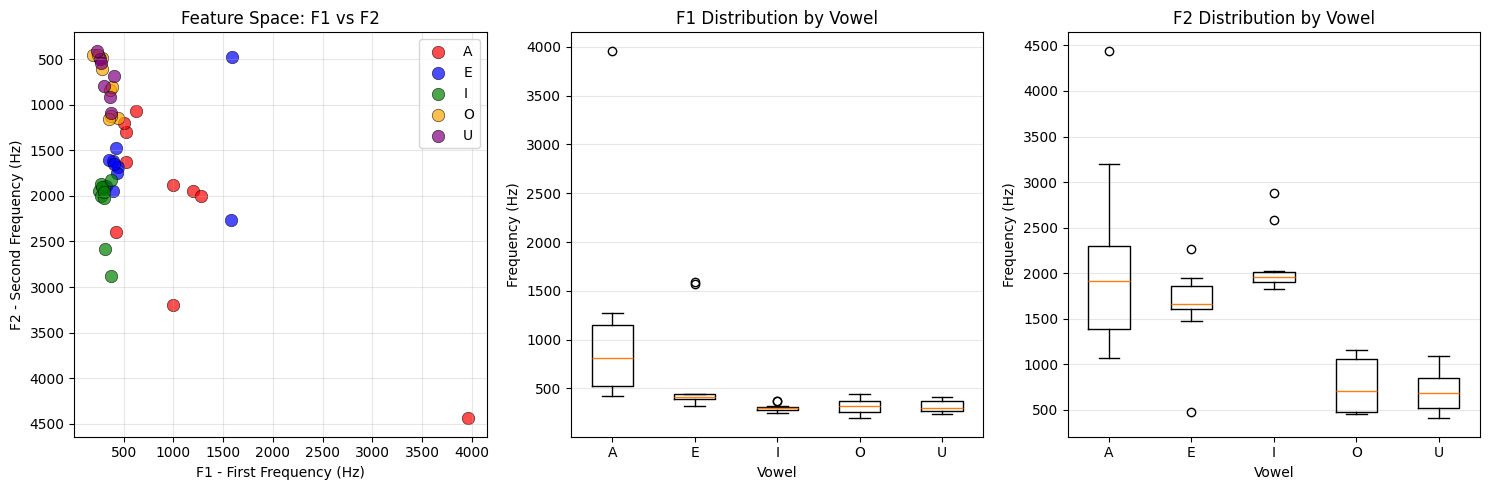

In [18]:
unique_labels, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
colors = {'A': 'red', 'E': 'blue', 'I': 'green', 'O': 'orange', 'U': 'purple'}

for label in unique_labels:
    mask = y == label
    plt.scatter(X[mask, 0], X[mask, 1], 
                c=colors[label], 
                label=label, 
                alpha=0.7,
                s=80,
                edgecolors='black',
                linewidth=0.5)

plt.xlabel('F1 - First Frequency (Hz)')
plt.ylabel('F2 - Second Frequency (Hz)')
plt.title('Feature Space: F1 vs F2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.gca().invert_yaxis()

plt.subplot(1, 3, 2)
f1_by_vowel = []
for label in unique_labels:
    f1_by_vowel.append(X[y == label, 0])

plt.boxplot(f1_by_vowel, tick_labels=unique_labels)
plt.xlabel('Vowel')
plt.ylabel('Frequency (Hz)')
plt.title('F1 Distribution by Vowel')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 3, 3)
f2_by_vowel = []
for label in unique_labels:
    f2_by_vowel.append(X[y == label, 1])

plt.boxplot(f2_by_vowel, tick_labels=unique_labels)
plt.xlabel('Vowel')
plt.ylabel('Frequency (Hz)')
plt.title('F2 Distribution by Vowel')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 2. Split

Split the data into `test`and `train` using `train_test_split` from `sklearn`

In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None)
print(X_train)
print(y_train)
print("-----------------")
print(X_test)
print(y_test)

[[ 375.         2875.        ]
 [ 384.61538462  807.69230769]
 [ 250.         1950.        ]
 [ 272.67562962  536.26207158]
 [ 525.         1300.        ]
 [ 300.          790.        ]
 [ 428.69901756 1743.37600476]
 [ 625.         1071.42857143]
 [1000.52110474 1875.97707139]
 [ 236.71497585  449.27536232]
 [ 232.55813953  404.65116279]
 [ 352.94117647 1600.        ]
 [ 323.80952381 1895.23809524]
 [ 441.17647059 1676.47058824]
 [1275.         2000.        ]
 [ 355.63787914 1155.8231072 ]
 [ 526.31578947 1631.57894737]
 [ 272.7789354  1863.98939193]
 [1200.         1942.85714286]
 [ 272.72727273 2000.        ]
 [ 192.30769231  455.12820513]
 [ 423.52941176 1470.58823529]
 [ 300.         1900.        ]
 [ 505.88235294 1200.        ]
 [ 375.         1087.5       ]
 [ 406.59340659  681.31868132]
 [ 285.71428571  609.52380952]
 [ 263.15789474  500.        ]
 [ 424.65753425 2397.26027397]
 [ 387.09677419 1946.23655914]
 [ 315.78947368 2578.94736842]
 [ 375.         1125.        ]
 [ 300. 

## 3. SVM

Accuracy: 0.70


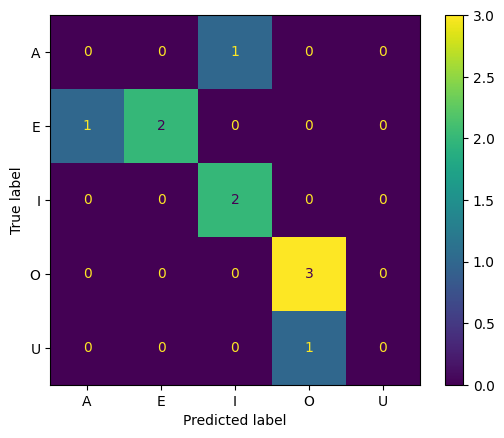

In [126]:
from sklearn import svm
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
clf = svm.SVC()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

## 4. DecisionTree

Accuracy: 0.60


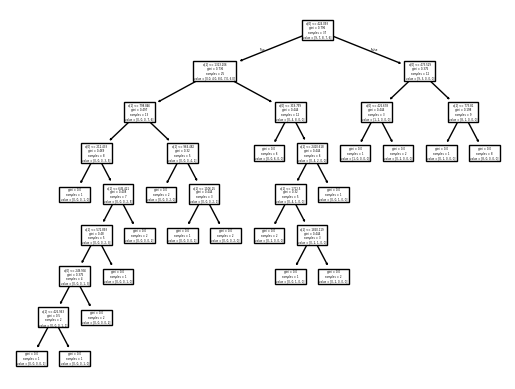

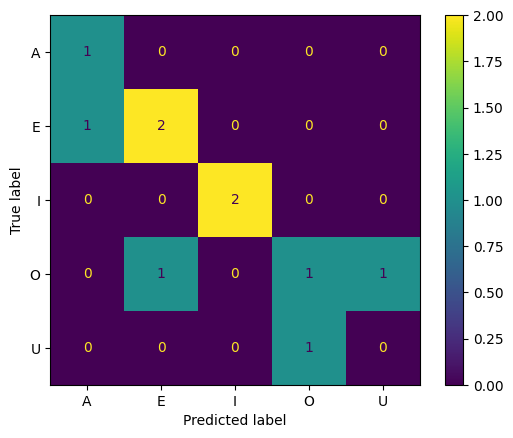

In [131]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
prediction = clf.predict(X_test)

plot_tree(clf)
ConfusionMatrixDisplay.from_predictions(y_test,prediction)

accuracy = accuracy_score(y_test, prediction)
print(f"Accuracy: {accuracy:.2f}")

## 5. Random Forest

Accuracy: 0.60


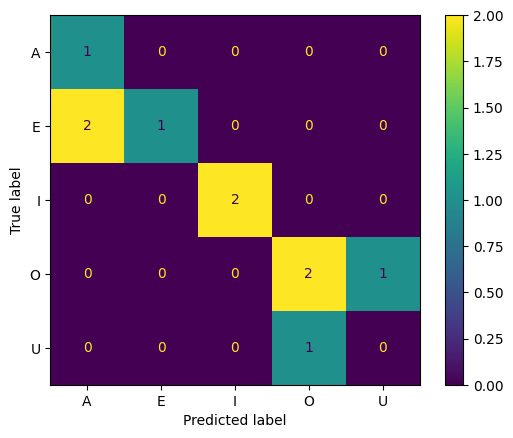

In [135]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=5)
clf.fit(X_train, y_train)
prediction = clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test,prediction)
accuracy = accuracy_score(y_test, prediction)
print(f"Accuracy: {accuracy:.2f}")